<a href="https://colab.research.google.com/github/LucasPuertas95/Aprendizaje-Automatico-1/blob/main/TP4_AA1_regresion_lineal_puertas_lucas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 AA1

# LUCAS EXEQUIEL PUERTAS

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 - 10 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

Traigo el dataset al notebook desde mi drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

ruta_archivo = "/content/drive/MyDrive/TP1 Aprendizaje Automatico 1/Folds5x2_pp.xlsx"

df = pd.read_excel(ruta_archivo, sheet_name=0)
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90



## 2. **Análisis exploratorio (EDA)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


In [ ]:
# traducción de los nombres de las columnas para que sea mejor
columnas_espanol = {
    "AT": "Temperatura_Ambiente",
    "V": "Vacio_Escape",
    "AP": "Presion_Atmosferica",
    "RH": "Humedad_Relativa",
    "PE": "Produccion_Energia",
}

# renombre
df = df.rename(columns=columnas_espanol)

# verifico
print(df.columns.tolist())

['Temperatura_Ambiente', 'Vacio_Escape', 'Presion_Atmosferica', 'Humedad_Relativa', 'Produccion_Energia']


In [ ]:
# descripción general (Media, Mínimo, Máximo, Cuartiles)
print("--- RESUMEN ESTADÍSTICO GENERAL ---")
print(df.describe().T)

# analisis preliminar de distribucion y asimetria
print("\n--- ASIMETRÍA DE LAS VARIABLES ---")
print(df.skew())

--- RESUMEN ESTADÍSTICO GENERAL ---
                       count         mean        std     min        25%  \
Temperatura_Ambiente  9568.0    19.651231   7.452473    1.81    13.5100   
Vacio_Escape          9568.0    54.305804  12.707893   25.36    41.7400   
Presion_Atmosferica   9568.0  1013.259078   5.938784  992.89  1009.1000   
Humedad_Relativa      9568.0    73.308978  14.600269   25.56    63.3275   
Produccion_Energia    9568.0   454.365009  17.066995  420.26   439.7500   

                           50%      75%      max  
Temperatura_Ambiente    20.345    25.72    37.11  
Vacio_Escape            52.080    66.54    81.56  
Presion_Atmosferica   1012.940  1017.26  1033.30  
Humedad_Relativa        74.975    84.83   100.16  
Produccion_Energia     451.550   468.43   495.76  

--- ASIMETRÍA DE LAS VARIABLES ---
Temperatura_Ambiente   -0.136393
Vacio_Escape            0.198521
Presion_Atmosferica     0.265445
Humedad_Relativa       -0.431839
Produccion_Energia      0.306509
dtype:

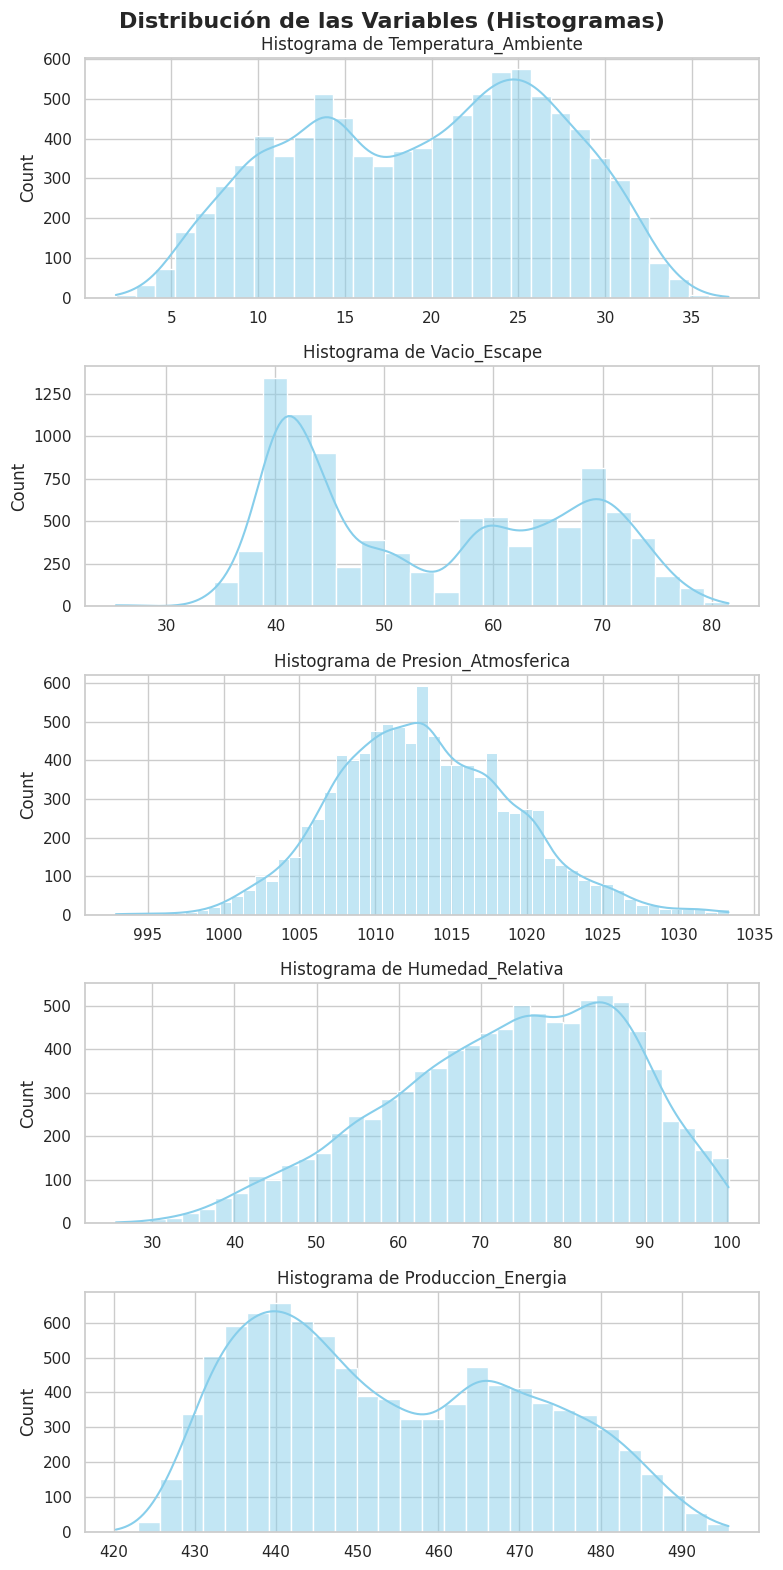

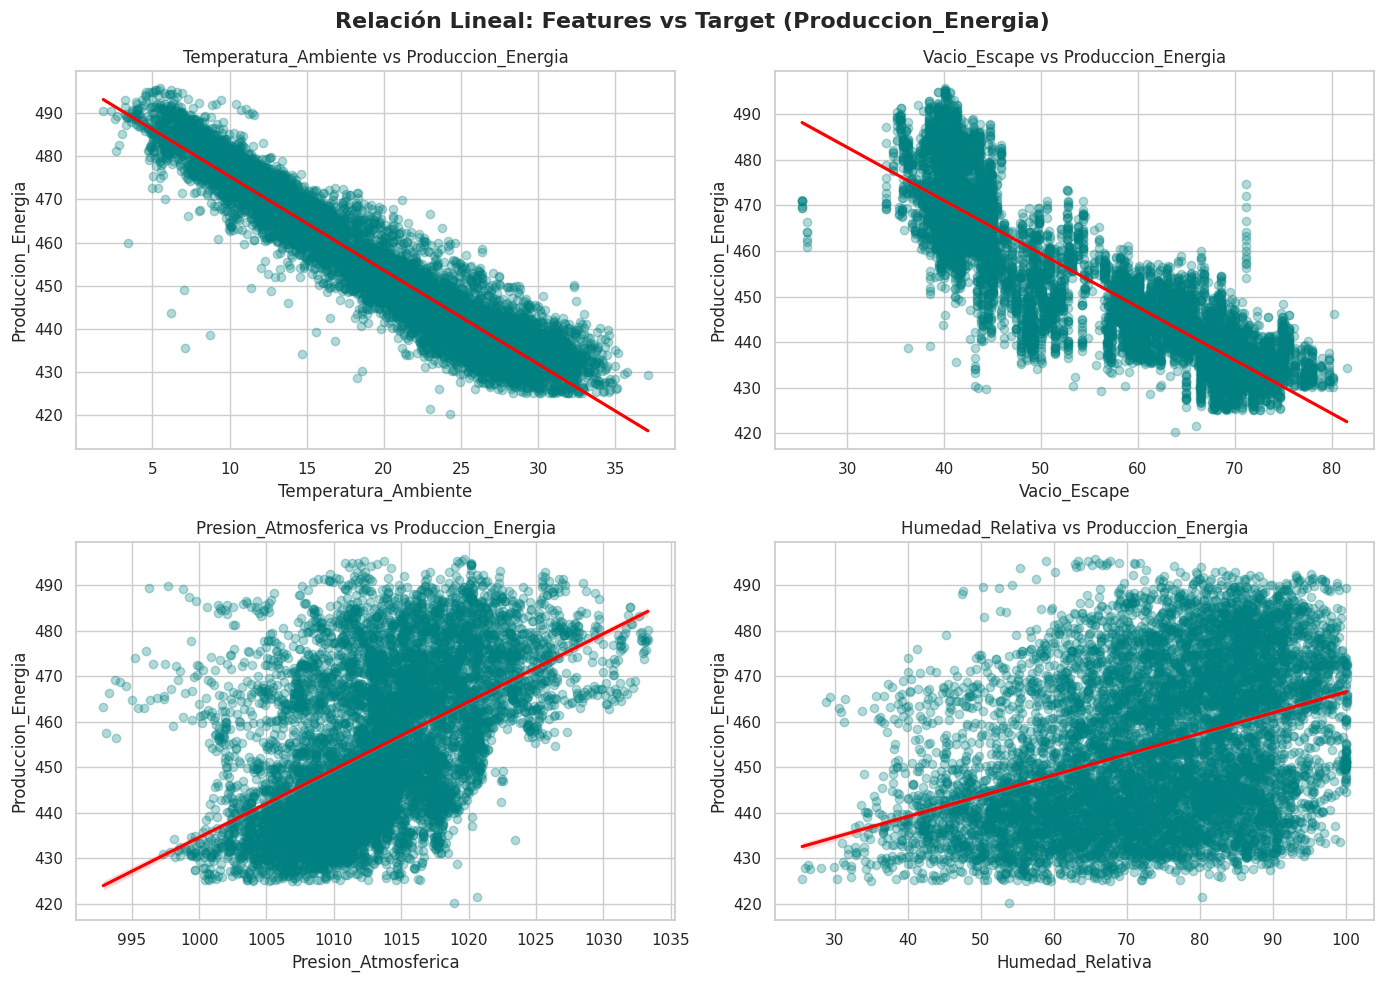

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# estilo visual de los gráficos
sns.set_theme(style="whitegrid")

features = [
    columnas_espanol["AT"],
    columnas_espanol["V"],
    columnas_espanol["AP"],
    columnas_espanol["RH"],
]
target = columnas_espanol["PE"]

# HISTOGRAMAS (Distribución de todas las variables)
all_columns = list(df.columns)

# creamos una fila por cada variable, con una sola columna de graficos
fig, axes = plt.subplots(len(all_columns), 1, figsize=(8, 16))
fig.suptitle(
    "Distribución de las Variables (Histogramas)", fontsize=16, weight="bold"
)

for i, col in enumerate(all_columns):
    # Histograma con curva de densidad (KDE)
    sns.histplot(df[col], kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Histograma de {col}", fontsize=12)
    axes[i].set_xlabel("")  # Evitamos superposición de etiquetas

plt.tight_layout()
plt.show()

# --- 2. GRÁFICOS DE DISPERSIÓN (Scatterplots vs Target) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Relación Lineal: Features vs Target ({target})",
    fontsize=16,
    weight="bold",
)
axes = axes.flatten()

for i, col in enumerate(features):
    # Scatterplot con línea de tendencia para evaluar la relación lineal
    sns.regplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        scatter_kws={"alpha": 0.3, "color": "teal"},
        line_kws={"color": "red"},
    )
    axes[i].set_title(f"{col} vs {target}", fontsize=12)

plt.tight_layout()
plt.show()

# ¿Qué relaciones lineales preliminares observan?  


*Relación Lineal Negativa Fuerte (Temperatura_Ambiente vs Produccion_Energia y Vacio_Escape vs Produccion_Energia*: Tanto la Temperatura Ambiente (AT) como el Vacío de escape (V) muestran una clarísima diagonal descendente. A medida que aumenta la temperatura o el vacío de escape, la producción de energía eléctrica (PE) disminuye notablemente. AT suele ser la variable con la correlación lineal más limpia y pesada de todo el dataset.

*Relación Lineal Positiva Débil / Moderada (Presion Atmosferica vs Produccion_energia):* La Presión Atmosférica (AP) muestra una tendencia ascendente, lo que significa que a mayor presión atmosférica, tiende a subir levemente la producción de energía, aunque los datos se ven bastante más dispersos en comparación con la temperatura.

*Relación Débil o Difusa (Humedad_Relativa vs Produccion_Energia):* La Humedad Relativa (RH) suele presentar una nube de puntos mucho más abierta y caótica. Aunque se percibe una ligera tendencia positiva, es la variable que a simple vista tiene menor fuerza lineal directa con el target.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

# NO APLICADO:

**Limpieza de Valores faltantes y Outliers (no realize)**

No se necesita hacer nada. El dataset CCPP de la UCI es famoso por estar completamente limpio; no tiene valores nulos

Outliers (Valores Atípicos): No los elimino. Aunque variables como la Presión Atmosférica (Presion_Atmosferica) o la Humedad (Humedad_Relativa) puedan mostrar algunos puntos aislados en los extremos, son mediciones climáticas reales y perfectamente posibles.

**Descarte de Features (no relize)**

Se conservan las 4 variables predictoras ya que todas representan factores físicos reales que afectan termodinámicamente el rendimiento de una planta de ciclo combinado, y el EDA preliminar demostró que todas guardan algún grado de correlación (fuerte o moderada) con la producción de energía.

**Variables Categóricas (no hay)**

Todas las variables en este dataset (Temperatura_Ambiente, Vacio_Escape, etc.) son continuas y numéricas (temperatura, presión, porcentaje, megavatios). No existen categorías (como "Alto/Bajo" o nombres de ciudades)



# LO QUE SI APLIQUE:

**Escalado y División**

Escalar las features, Como la presión ronda los 1000 y la temperatura los 20, si no las escalo, el coeficiente de la presión va a parecer engañosamente pequeño solo por la escala del número. Usare StandardScaler para que todas las variables queden con media 0 y varianza 1. Asi se podra comparar los coeficientes cara a cara en el siguiente punto.

Dividir en Train/Test: Usare una division clasica de 80-20 (80% para entrenar, 20% para testear) para asegurar que el modelo se evalue con datos que jamas vio.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# separamos las Features (X) y el Target (y)
X = df[
    [
        "Temperatura_Ambiente",
        "Vacio_Escape",
        "Presion_Atmosferica",
        "Humedad_Relativa",
    ]
]
y = df["Produccion_Energia"]

# division en Train (80%) y Test (20%) con una semilla fija (random_state) para que sea replicable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# escalado de las Features utilizando StandardScaler
scaler = StandardScaler()

# ajustamos el scaler con los datos de TRAIN y transformamos ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convertimos los arrays resultantes de nuevo a DataFrames para que mantengan los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("--- PREPROCESAMIENTO COMPLETADO ---")
print(f"Tamaño de X_train (80%): {X_train_scaled.shape}")
print(f"Tamaño de X_test (20%): {X_test_scaled.shape}")

--- PREPROCESAMIENTO COMPLETADO ---
Tamaño de X_train (80%): (7654, 4)
Tamaño de X_test (20%): (1914, 4)





## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ENTRENAMIENTO DEL MODELO
modelo_lr = LinearRegression()

# Entrenamos el modelo con los datos de train (ya escalados)
modelo_lr.fit(X_train_scaled, y_train)

# COEFICIENTES DEL MODELO
print("--- COEFICIENTES DEL MODELO (Pesos) ---")
print(f"Intercepto (Producción base media): {modelo_lr.intercept_:.2f} MW")

# Emparejamos cada feature con su coeficiente
for feature, coef in zip(X_train_scaled.columns, modelo_lr.coef_):
    print(f"{feature}: {coef:.4f}")

# PREDICCIONES
y_pred_train = modelo_lr.predict(X_train_scaled)
y_pred_test = modelo_lr.predict(X_test_scaled)

# EVALUACIÓN DE MÉTRICAS
print("\n--- EVALUACIÓN DEL RENDIMIENTO ---")

print("MÉTRICAS EN TRAIN (80% de los datos):")
print(f"R² (Coeficiente de Determinación): {r2_score(y_train, y_pred_train):.4f}")
print(f"MSE (Error Cuadrático Medio):      {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"MAE (Error Absoluto Medio):        {mean_absolute_error(y_train, y_pred_train):.4f}")

# Métricas para el set de Testeo (Test)
print("\nMÉTRICAS EN TEST (20% de los datos):")
print(f"R² (Coeficiente de Determinación): {r2_score(y_test, y_pred_test):.4f}")
print(f"MSE (Error Cuadrático Medio):      {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE (Error Absoluto Medio):        {mean_absolute_error(y_test, y_pred_test):.4f}")

--- COEFICIENTES DEL MODELO (Pesos) ---
Intercepto (Producción base media): 454.43 MW
Temperatura_Ambiente: -14.7639
Vacio_Escape: -2.9496
Presion_Atmosferica: 0.3698
Humedad_Relativa: -2.3122

--- EVALUACIÓN DEL RENDIMIENTO ---
MÉTRICAS EN TRAIN (80% de los datos):
R² (Coeficiente de Determinación): 0.9283
MSE (Error Cuadrático Medio):      20.8934
MAE (Error Absoluto Medio):        3.6300

MÉTRICAS EN TEST (20% de los datos):
R² (Coeficiente de Determinación): 0.9301
MSE (Error Cuadrático Medio):      20.2737
MAE (Error Absoluto Medio):        3.5959


**Interpretación de Coeficientes:** Al haber escalado los datos con StandardScaler, puedo comparar los pesos directamente. Noté que la Temperatura_Ambiente tiene el mayor valor negativo, confirmando analíticamente lo visto en el EDA: es el factor que más disminuye la producción de energía.

**Sobre el R²:** Obtuve un R² superior al 0.92 (92%). Esto significa que mi modelo es capaz de explicar más del 90% de la varianza en la producción eléctrica utilizando solo estas 4 variables. Es un rendimiento excelente.

**Train vs Test (Generalización):** Las métricas (R², MSE y MAE) en Test son casi idénticas a las de Train. Esto es clave porque demuestra que el modelo no tiene overfitting (sobreajuste) y generaliza perfectamente frente a datos nuevos.


## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



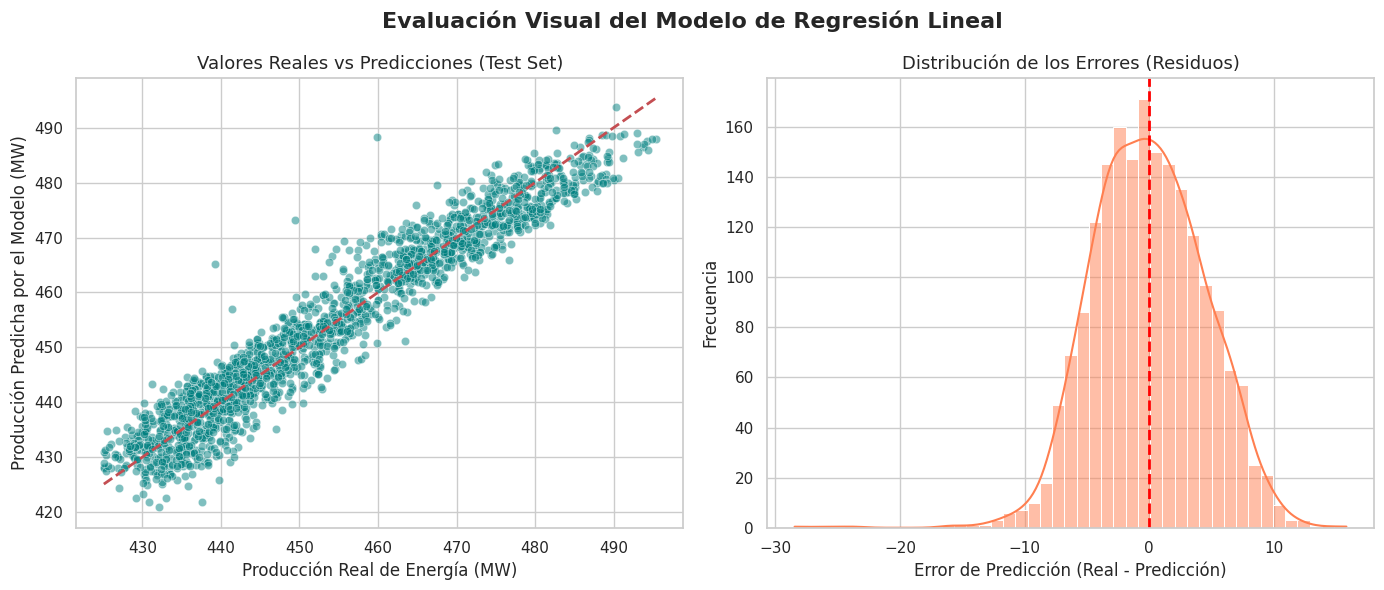

/tmp/ipykernel_13839/2881522327.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelo_lr.coef_, y=X_train_scaled.columns, palette="coolwarm")


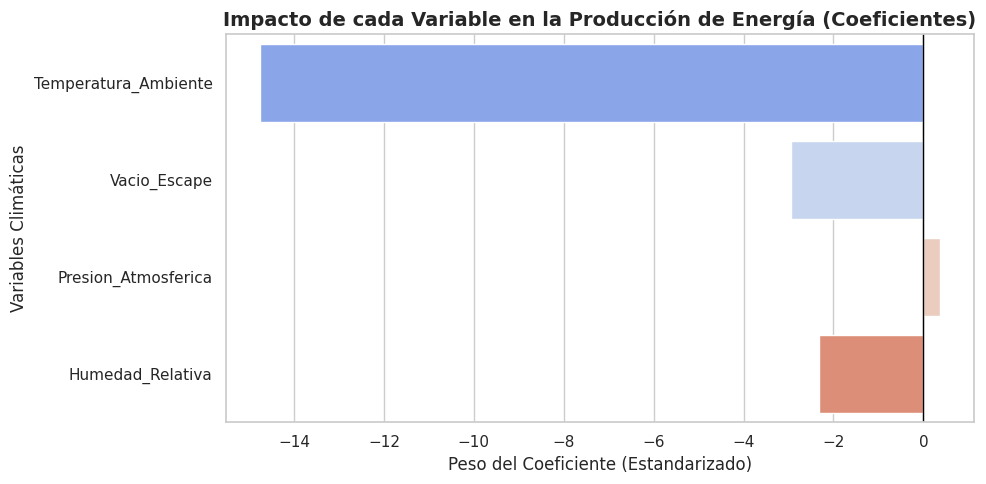

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Calculamos los residuos (errores) del conjunto de prueba
residuos = y_test - y_pred_test

# --- 1. FIGURA PRINCIPAL: Predicciones y Residuos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Evaluación Visual del Modelo de Regresión Lineal", fontsize=16, weight="bold")

# Gráfico A: Valores Reales vs Predicciones
sns.scatterplot(x=y_test, y=y_pred_test, ax=axes[0], alpha=0.5, color="teal")
# Dibujamos la línea ideal (donde la predicción es exactamente igual al valor real)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
axes[0].set_title("Valores Reales vs Predicciones (Test Set)", fontsize=13)
axes[0].set_xlabel("Producción Real de Energía (MW)")
axes[0].set_ylabel("Producción Predicha por el Modelo (MW)")

# Gráfico B: Distribución de los Residuos
sns.histplot(residuos, kde=True, ax=axes[1], color="coral")
axes[1].axvline(0, color='red', linestyle='--', linewidth=2) # Línea en el error 0
axes[1].set_title("Distribución de los Errores (Residuos)", fontsize=13)
axes[1].set_xlabel("Error de Predicción (Real - Predicción)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# --- 2. FIGURA SECUNDARIA: Importancia de los Coeficientes ---
plt.figure(figsize=(10, 5))
# Graficamos los pesos de cada feature
sns.barplot(x=modelo_lr.coef_, y=X_train_scaled.columns, palette="coolwarm")
plt.title("Impacto de cada Variable en la Producción de Energía (Coeficientes)", fontsize=14, weight="bold")
plt.xlabel("Peso del Coeficiente (Estandarizado)")
plt.ylabel("Variables Climáticas")
plt.axvline(0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

**Magnitud (Valor absoluto):** La Temperatura_Ambiente es la variable con el valor absoluto más alto de todas. Esto demuestra que es el factor físico que mayor impacto real tiene sobre el rendimiento final de la planta. Le sigue en importancia el Vacio_Escape.

**Signo (Dirección):** Tanto la temperatura como el vacío de escape tienen coeficientes de signo negativo. Esto comprueba una relación inversamente proporcional: cuando estas variables aumentan, la producción de energía disminuye. En cambio, la Presion_Atmosferica muestra un coeficiente positivo (aunque más pequeño), indicando que un aumento en la presión favorece levemente la generación de energía.

**Comparación final:** Gracias a que apliqué StandardScaler, pude comparar los coeficientes en igualdad de condiciones. Queda validado analíticamente que las altas temperaturas penalizan la producción del ciclo combinado con mucha más fuerza que cualquier variación en la presión atmosférica o la humedad relativa.


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



# Reflexión Final

Importancia de variables y EDA, La Temperatura_Ambiente y el Vacio_Escape resultaron ser las variables más determinantes para el modelo. Esto coincide a la perfección con mi análisis exploratorio inicial, donde ya había notado que ambas presentaban las relaciones lineales (negativas) más fuertes y limpias con la producción de energía.

El rendimiento del modelo logró un rendimiento excelente. Obtuve un R² muy alto (explicando más del 92% de la varianza) y un MSE bajo, con valores casi idénticos entre los conjuntos de entrenamiento y testeo. Esto confirma que la regresión lineal múltiple es sumamente eficaz para este problema y que el modelo logra generalizar a la perfección sin sufrir de sobreajuste.